##1. 데이터 불러오기
-----

In [3]:
# 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve

# CSV 파일 경로 설정
file_path = "/content/diabetes.csv"

# CSV 파일을 데이터프레임으로 불러오기
df = pd.read_csv(file_path)

# 데이터 샘플 상위 5개 행 출력
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# 각 컬럼의 속성 및 결측치 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# 각 컬럼의 통계치 확인
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 왜도와 첨도 출력
for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurt()
    print(f"{col:<25} | 왜도(Skew): {skew:.2f}  | 첨도(Kurtosis): {kurt:.2f}")

Pregnancies               | 왜도(Skew): 0.90  | 첨도(Kurtosis): 0.16
Glucose                   | 왜도(Skew): 0.17  | 첨도(Kurtosis): 0.64
BloodPressure             | 왜도(Skew): -1.84  | 첨도(Kurtosis): 5.18
SkinThickness             | 왜도(Skew): 0.11  | 첨도(Kurtosis): -0.52
Insulin                   | 왜도(Skew): 2.27  | 첨도(Kurtosis): 7.21
BMI                       | 왜도(Skew): -0.43  | 첨도(Kurtosis): 3.29
DiabetesPedigreeFunction  | 왜도(Skew): 1.92  | 첨도(Kurtosis): 5.59
Age                       | 왜도(Skew): 1.13  | 첨도(Kurtosis): 0.64
Outcome                   | 왜도(Skew): 0.64  | 첨도(Kurtosis): -1.60


##2. 데이터 시각화
-----
###2-1. 분포 시각화

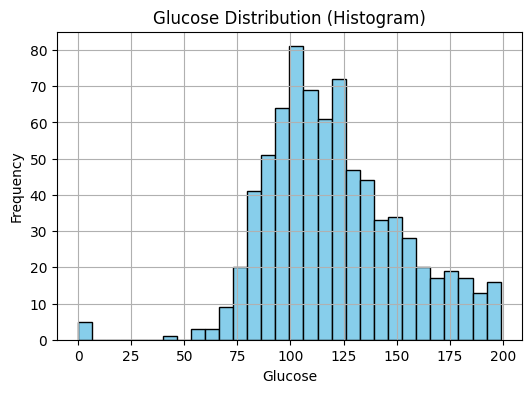

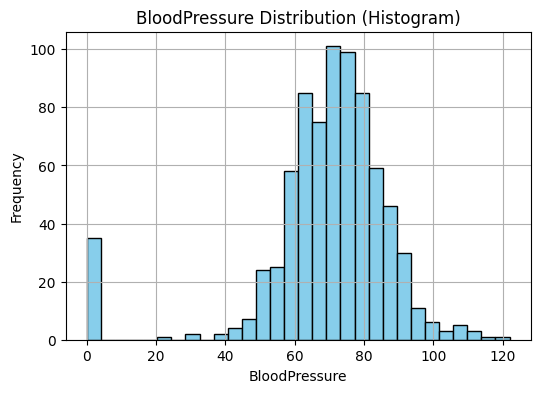

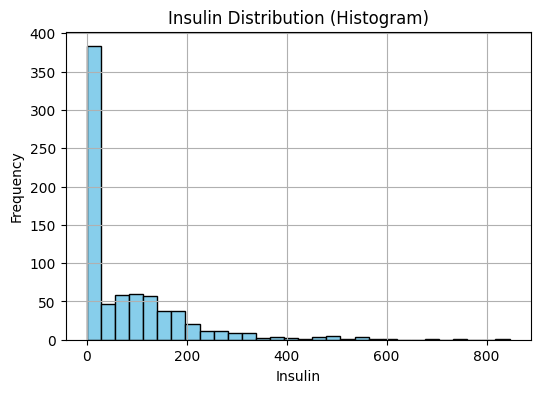

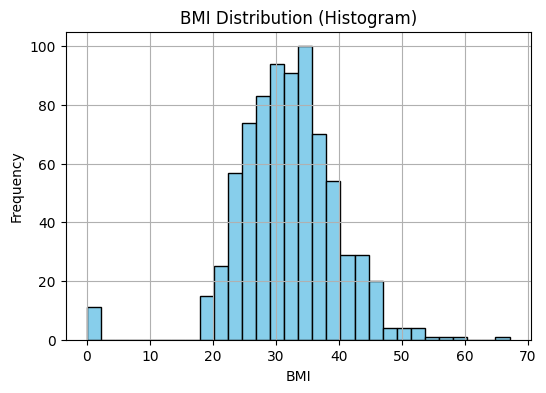

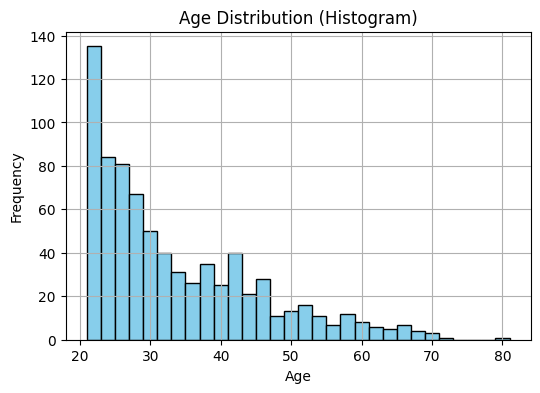

In [7]:
# 시각화할 컬럼 목록 설정
cols_to_plot = ['Glucose', 'BloodPressure', 'Insulin', 'BMI', 'Age']

# 각 변수별 히스토그램 출력
for col in cols_to_plot:
    plt.figure(figsize=(6, 4))  # 그래프 크기 설정
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')  # 히스토그램 생성
    plt.title(f'{col} Distribution (Histogram)')  # 그래프 제목
    plt.xlabel(col)  # x축 라벨
    plt.ylabel('Frequency')  # y축 라벨
    plt.grid(True)  # 격자 표시
    plt.show()  # 그래프 출력

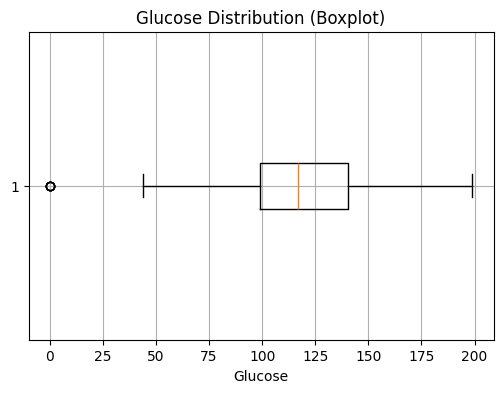

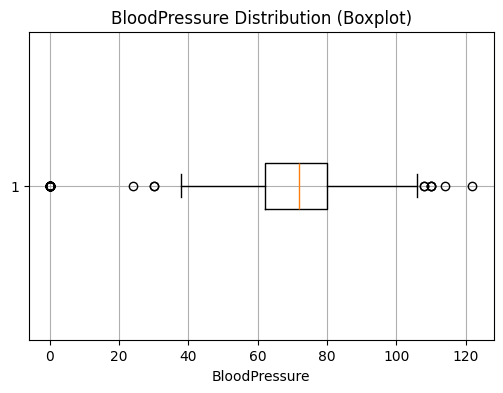

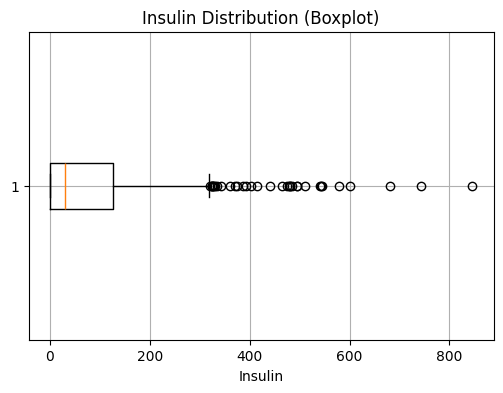

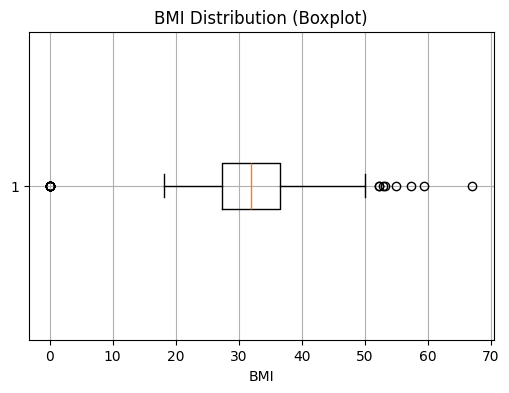

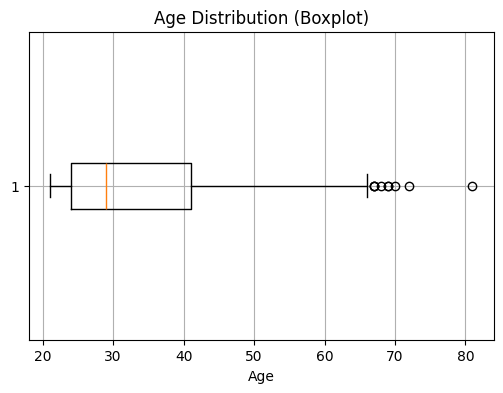

In [8]:
# 각 변수별 박스플롯 출력
for col in cols_to_plot:
    plt.figure(figsize=(6, 4))  # 그래프 크기 설정
    plt.boxplot(df[col], vert=False)  # 가로 방향 박스플롯 생성
    plt.title(f'{col} Distribution (Boxplot)')  # 그래프 제목
    plt.xlabel(col)  # x축 라벨 설정
    plt.grid(True)  # 격자 표시
    plt.show()  # 그래프 출력

-----
##2-2. 관계 시각화

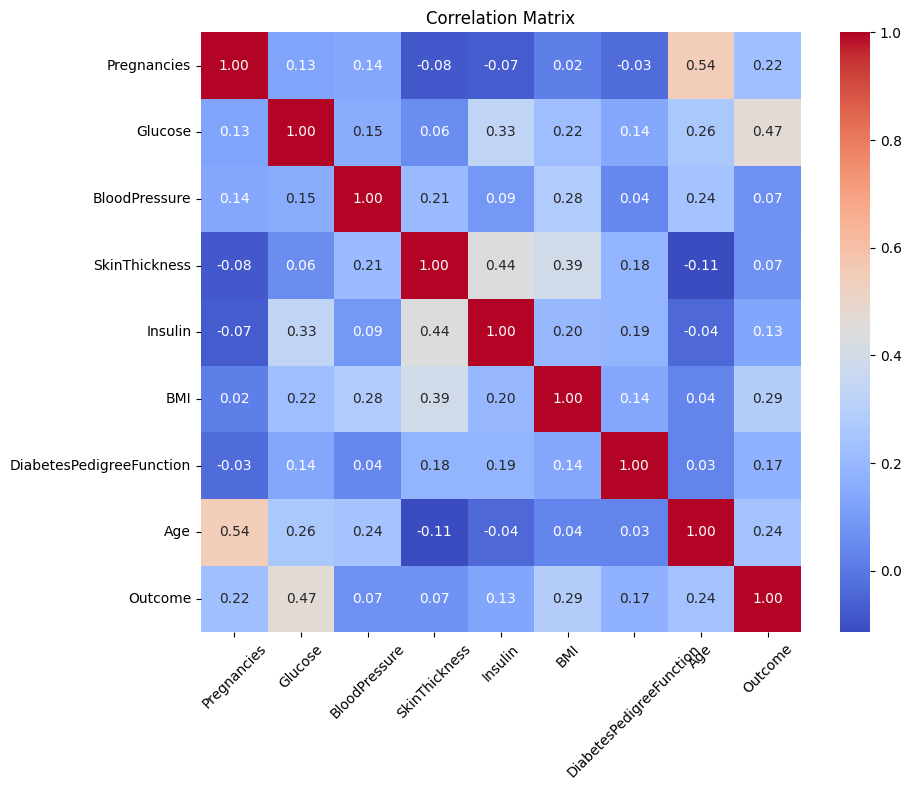

In [9]:
# 각 변수 간 상관계수 행렬 계산
correlation_matrix = df.corr()

# 상관계수 행렬을 히트맵 형태로 시각화
plt.figure(figsize=(10, 8))  # 그래프 크기 설정
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)  # 히트맵 생성
plt.title("Correlation Matrix")  # 제목 설정
plt.xticks(rotation=45)  # x축 라벨 회전
plt.yticks(rotation=0)   # y축 라벨 회전 없음
plt.tight_layout()  # 레이아웃 자동 정렬
plt.show()  # 그래프 출력

-----
###2-3. 비교 시각화

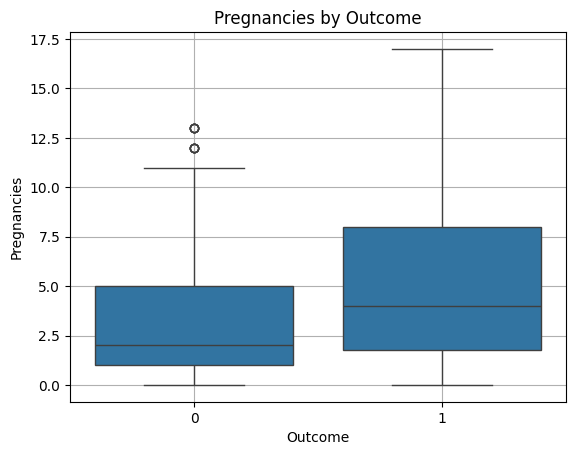

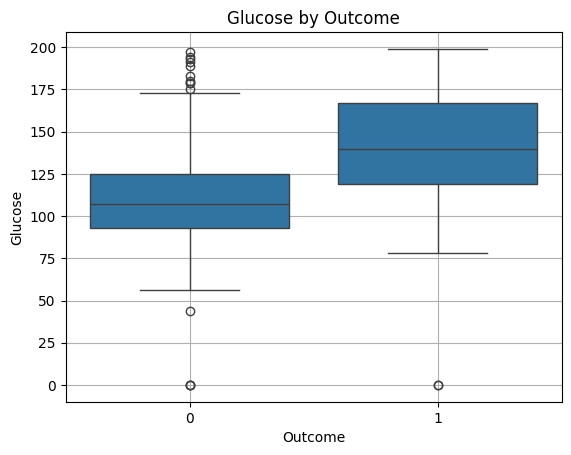

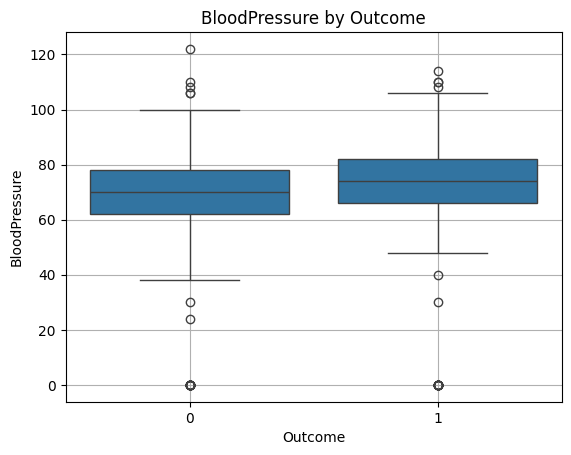

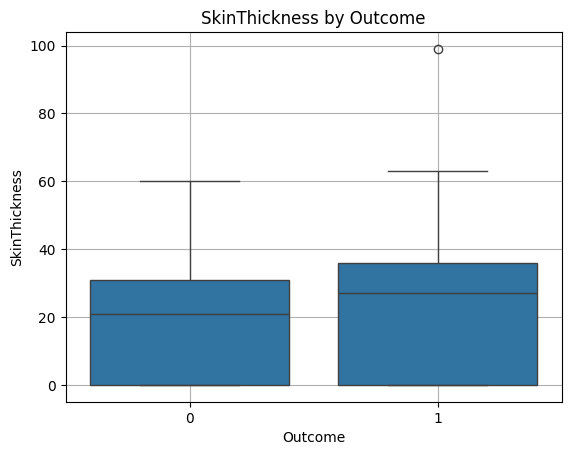

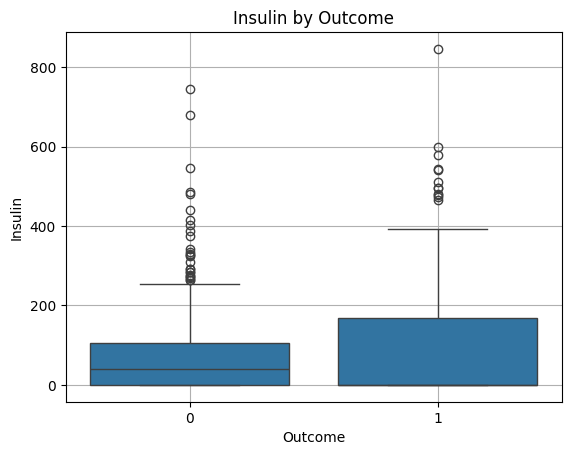

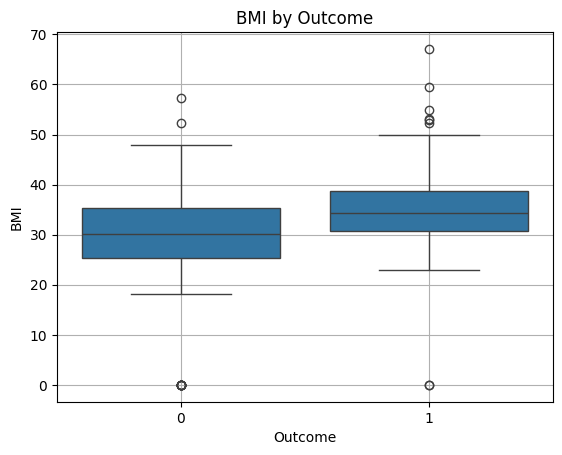

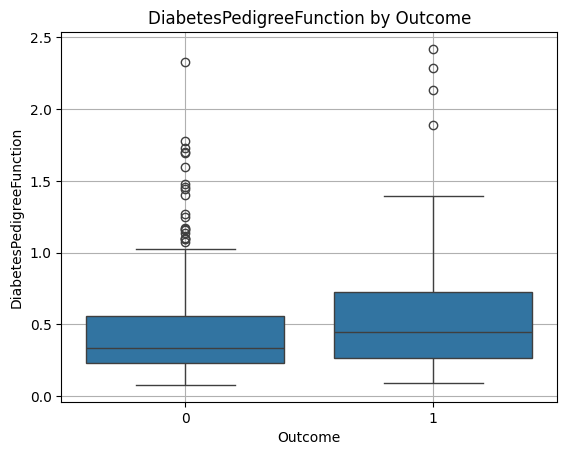

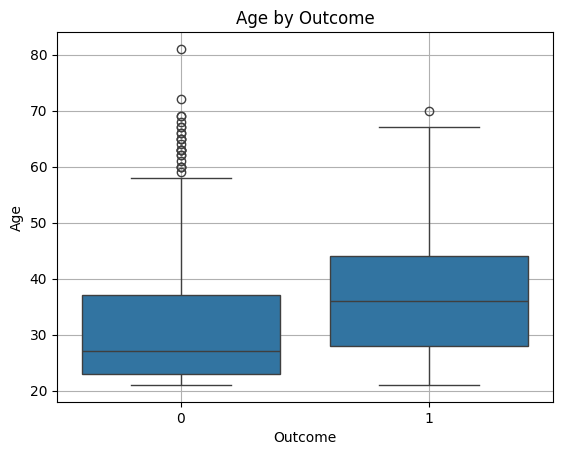

In [10]:
# 수치형 변수만 선택 (Outcome 제외 가능)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Outcome을 기준으로 각 수치형 변수 분포 비교 (Boxplot)
for col in numeric_cols:
    if col == 'Outcome':
        continue  # Outcome 자체는 비교 대상 아님
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'{col} by Outcome')  # 그래프 제목
    plt.xlabel('Outcome')  # x축 라벨
    plt.ylabel(col)  # y축 라벨
    plt.grid(True)  # 격자 표시
    plt.show()  # 그래프 출력




##3. 이상치 처리
-----

이상치 제거 전: (768, 9)
이상치 제거 후: (636, 9)


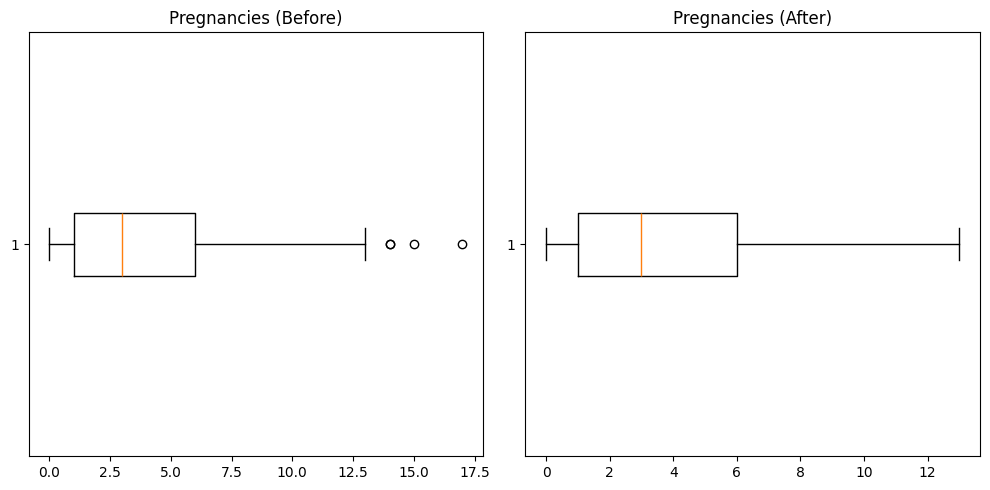

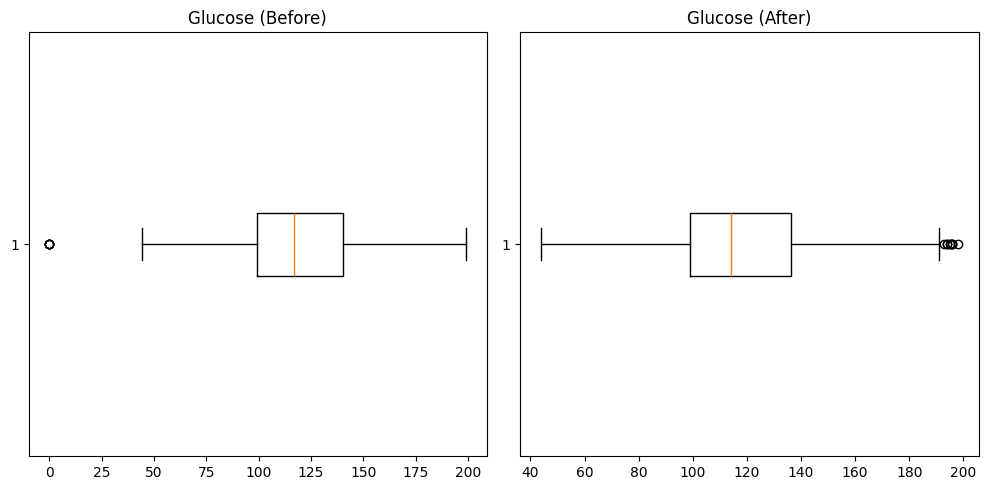

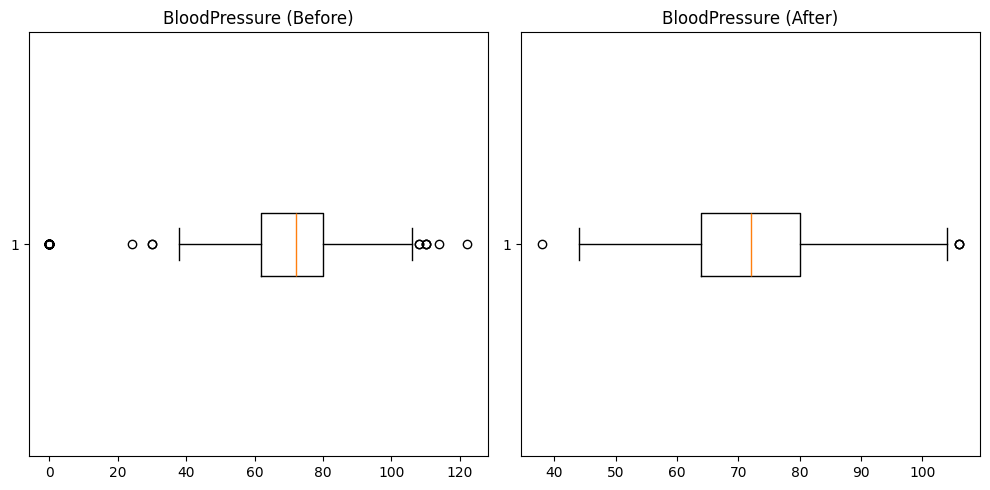

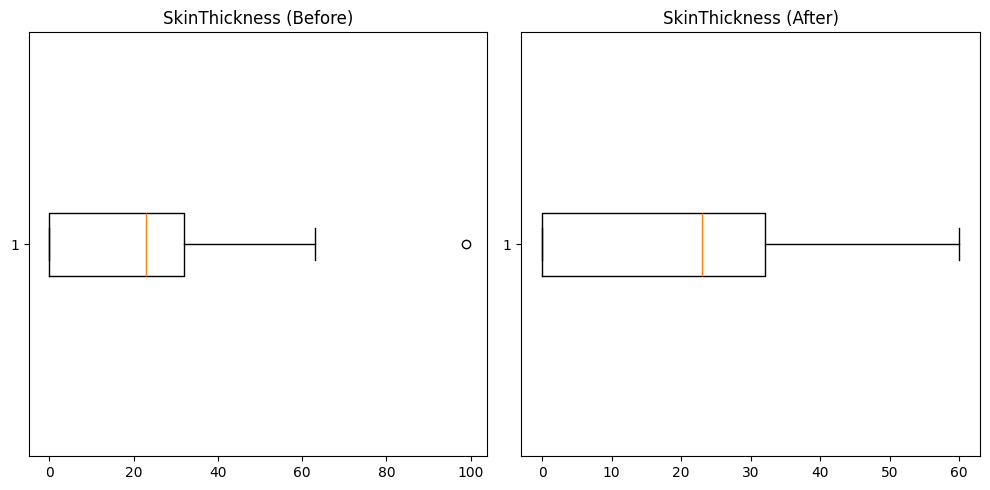

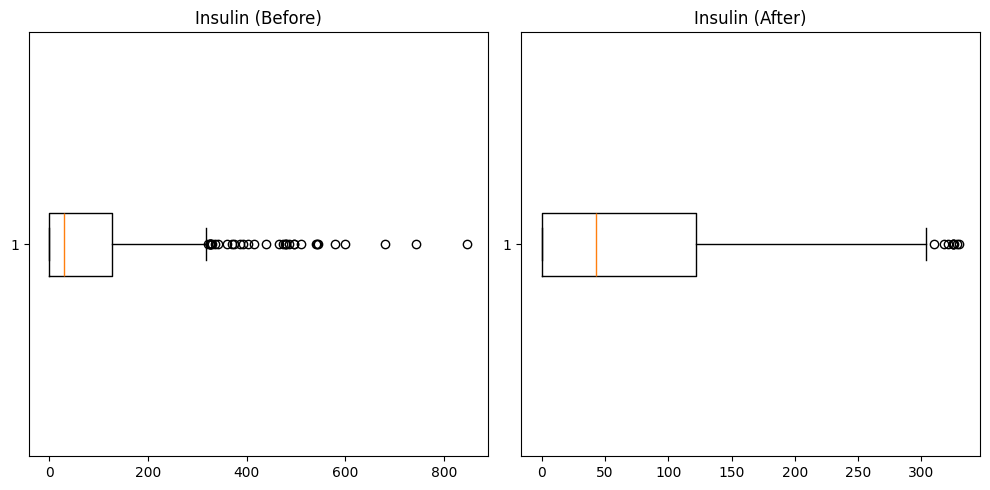

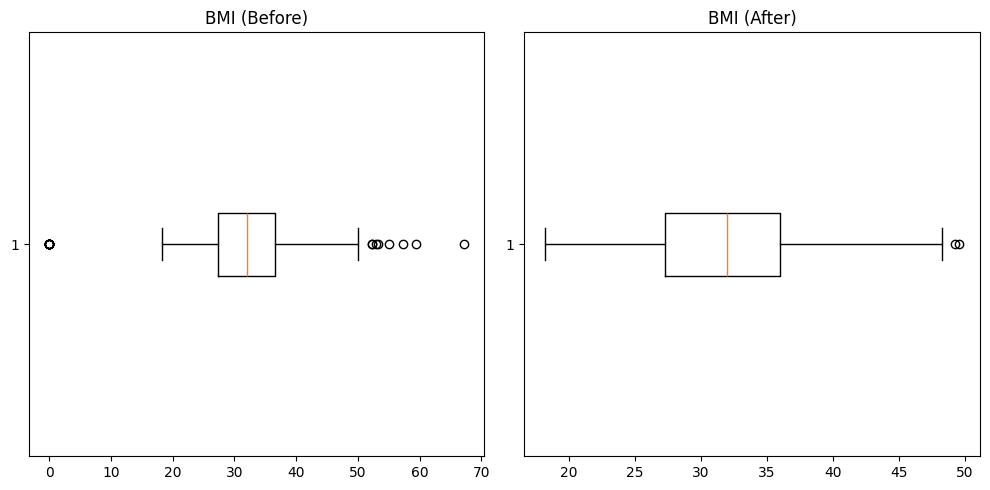

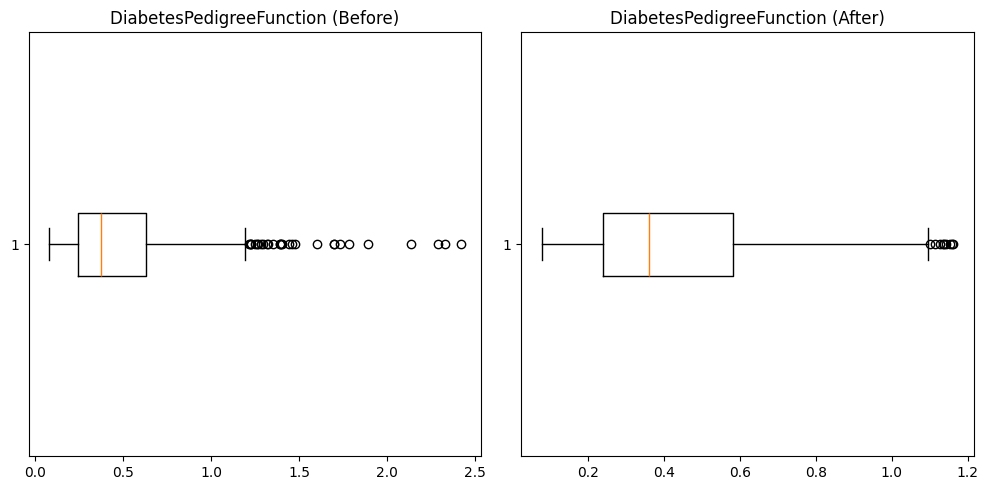

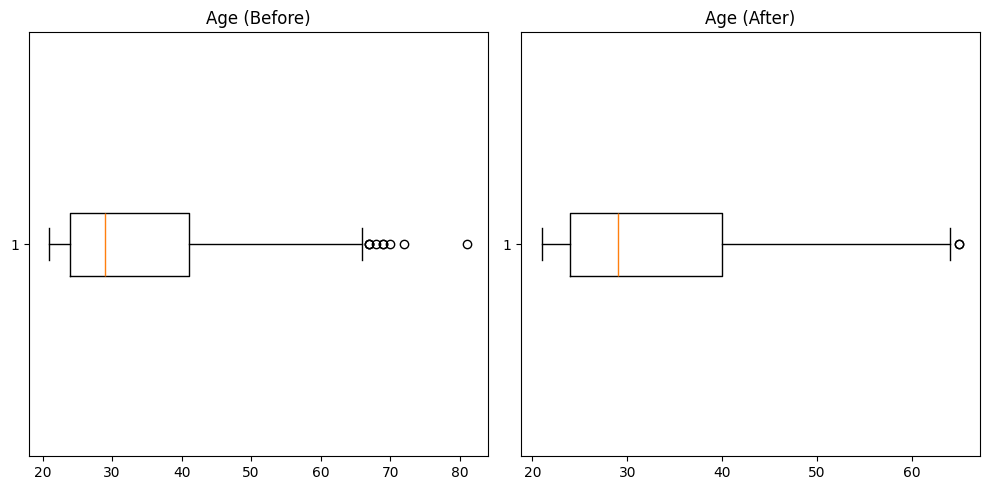

In [11]:
# 이상치 제거 전 데이터 복사
df_before = df.copy()
original_shape = df.shape

# 수치형 변수 목록에서 Outcome 제외
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
cols_to_check = [col for col in numeric_cols if col != 'Outcome']

# 이상치 제거 수행
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# 이상치 제거 전후 행 개수 출력
print("이상치 제거 전:", original_shape)
print("이상치 제거 후:", df.shape)

# 박스플롯 시각화 비교
for col in cols_to_check:
    plt.figure(figsize=(10, 5))

    # 제거 전 박스플롯
    plt.subplot(1, 2, 1)
    plt.boxplot(df_before[col], vert=False)
    plt.title(f"{col} (Before)")

    # 제거 후 박스플롯
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col], vert=False)
    plt.title(f"{col} (After)")

    plt.tight_layout()
    plt.show()


In [12]:
# Outcome 클래스 분포 확인
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True))

Outcome
0    439
1    197
Name: count, dtype: int64
Outcome
0    0.690252
1    0.309748
Name: proportion, dtype: float64


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,3.786164,118.869497,72.007862,20.745283,69.017296,31.964151,0.426237,32.555031,0.309748
std,3.251388,28.996773,11.301102,15.231688,83.601857,6.384132,0.245088,10.879807,0.462754
min,0.000000,44.000000,38.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.300000,0.238750,24.000000,0.000000
50%,3.000000,114.000000,72.000000,23.000000,42.500000,32.000000,0.361000,29.000000,0.000000
75%,6.000000,136.250000,80.000000,32.000000,122.000000,36.000000,0.583000,40.000000,1.000000
max,13.000000,198.000000,106.000000,60.000000,330.000000,49.600000,1.162000,65.000000,1.000000


##4. 변수 구간화
-----

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


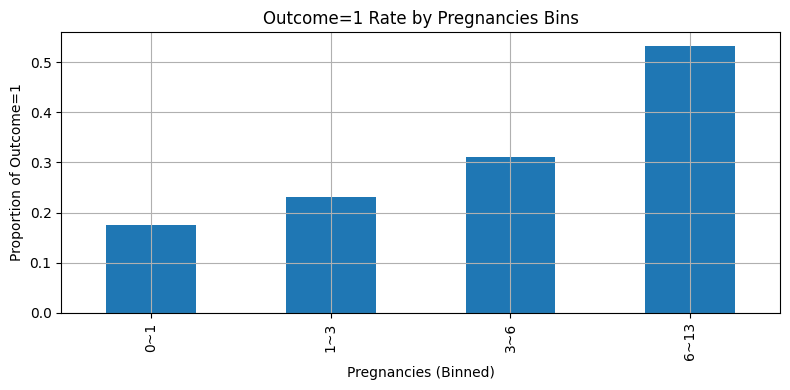

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


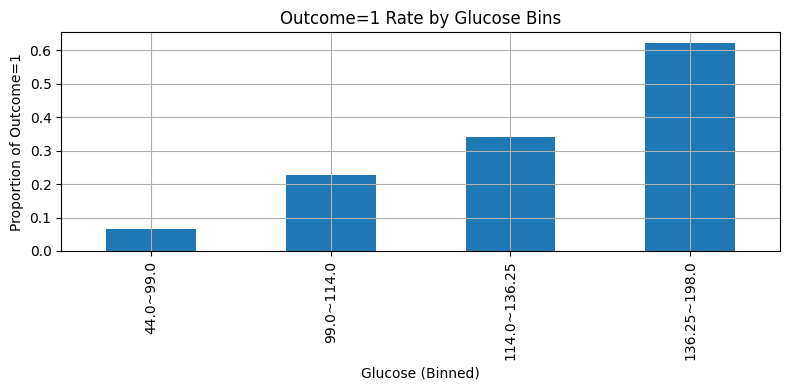

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


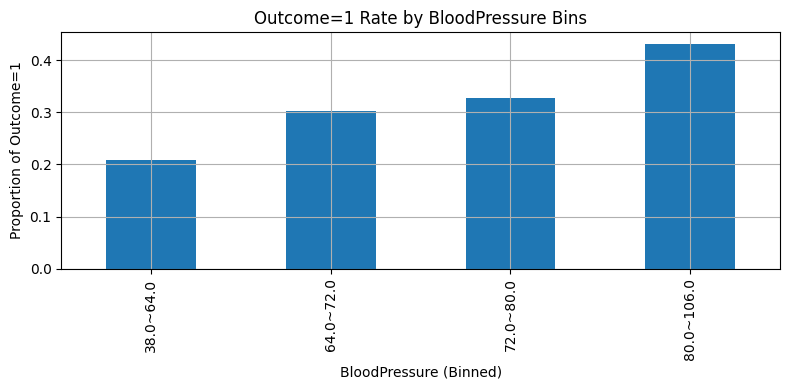

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


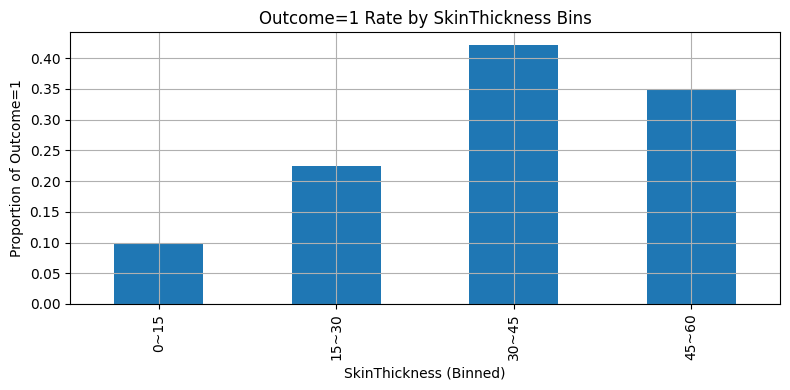

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


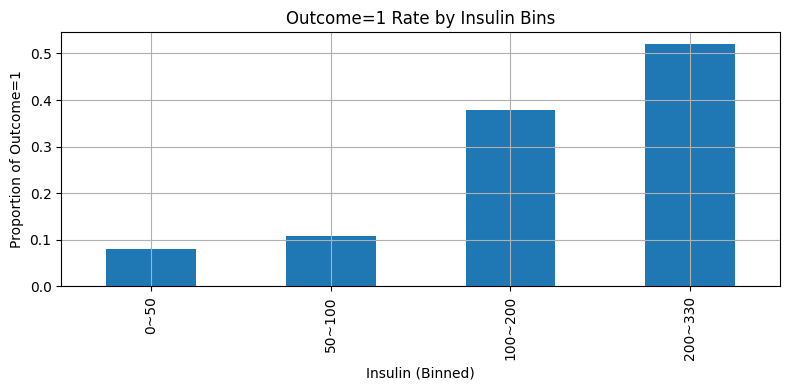

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


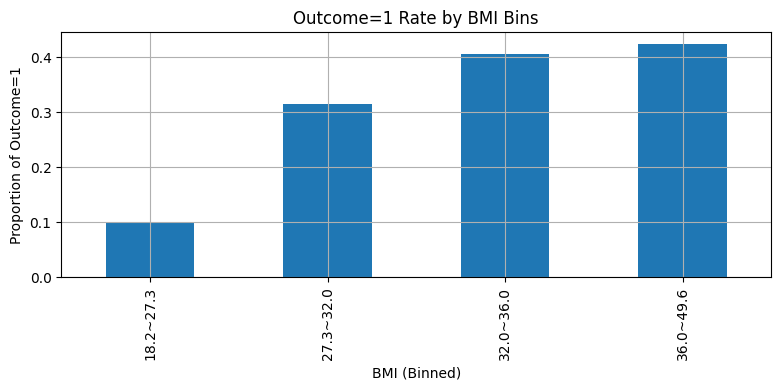

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


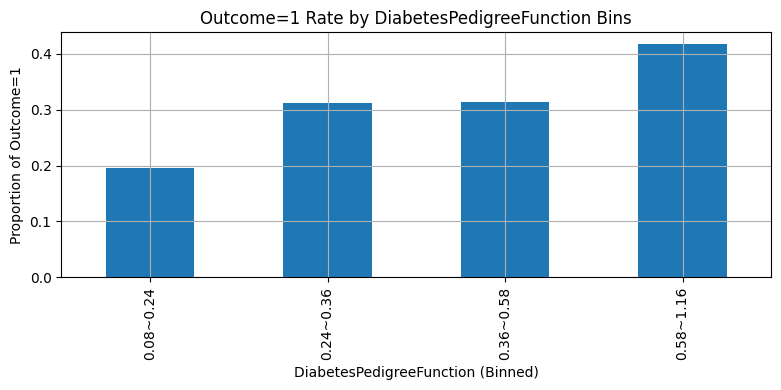

/tmp/ipykernel_3691/870136216.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outcome_rate = df.groupby(bin_col)['Outcome'].mean()


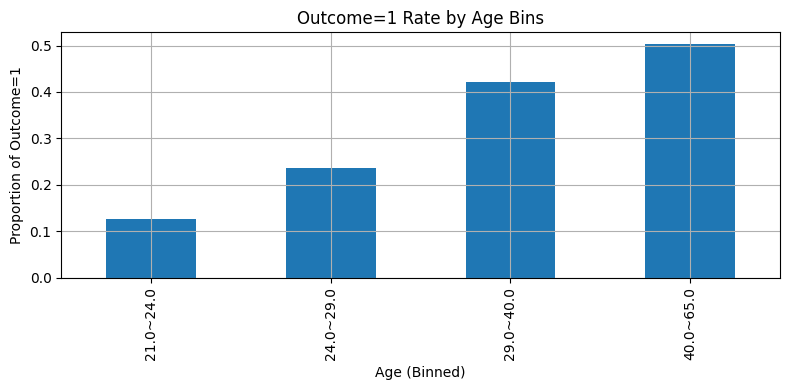

In [14]:
# 수치형 변수 중에서 Outcome 제외
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'Outcome']

# 각 변수별로 구간화하고 Outcome=1 비율을 시각화
for col in numeric_cols:
    bin_col = f'{col}_bin'  # 기존 컬럼은 그대로 두고, 구간화된 값을 저장할 새 컬럼 생성

    # Pregnancies, SkinThickness, Insulin은 수동으로 구간 지정하여 cut 사용
    if col == 'Pregnancies':
        bins = [0, 1, 3, 6, 13]
        labels = [f'{round(bins[i], 2)}~{round(bins[i+1], 2)}' for i in range(len(bins)-1)]
        df[bin_col] = pd.cut(df[col], bins=bins, labels=labels)

    elif col == 'SkinThickness':
        bins = [0, 15, 30, 45, 60]
        labels = [f'{round(bins[i], 2)}~{round(bins[i+1], 2)}' for i in range(len(bins)-1)]
        df[bin_col] = pd.cut(df[col], bins=bins, labels=labels)

    elif col == 'Insulin':
        bins = [0, 50, 100, 200, 330]
        labels = [f'{round(bins[i], 2)}~{round(bins[i+1], 2)}' for i in range(len(bins)-1)]
        df[bin_col] = pd.cut(df[col], bins=bins, labels=labels)

    # 나머지 변수는 분위수 기반 자동 구간화하되 라벨은 수동 생성
    else:
        qcut_result, bins = pd.qcut(df[col], q=4, retbins=True, duplicates='drop')  # 분위 구간 및 경계 추출
        labels = [f'{round(bins[i], 2)}~{round(bins[i+1], 2)}' for i in range(len(bins)-1)]  # 반올림된 라벨 생성
        df[bin_col] = pd.qcut(df[col], q=4, labels=labels, duplicates='drop')  # 라벨 지정하여 구간화

    # 구간별로 Outcome = 1의 비율 계산
    outcome_rate = df.groupby(bin_col)['Outcome'].mean()

    # 구간별 Outcome 비율을 막대 그래프로 시각화
    plt.figure(figsize=(8, 4))
    outcome_rate.plot(kind='bar')
    plt.title(f'Outcome=1 Rate by {col} Bins')
    plt.xlabel(f'{col} (Binned)')
    plt.ylabel('Proportion of Outcome=1')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


##5. 데이터 표준화
-----

In [15]:
# 표준화 대상 컬럼 지정 (Outcome 제외)
columns_to_scale = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# StandardScaler 객체 생성
scaler = StandardScaler()

# df에서 표준화할 컬럼들만 복사
data_to_scale = df[columns_to_scale].copy()

# 표준화 수행 (평균 0, 표준편차 1로 조정)
scaled_array = scaler.fit_transform(data_to_scale)

# 결과를 DataFrame으로 변환, 컬럼명 유지
df_scaled = pd.DataFrame(scaled_array, columns=columns_to_scale)

# 원래 Outcome 컬럼을 그대로 붙이기
df_scaled['Outcome'] = df['Outcome'].values

# 결과 확인
print(df_scaled.head())


   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.681426  1.005403      -0.000696       0.936596 -0.826197  0.256438   
1    -0.857590 -1.168963      -0.532036       0.542370 -0.826197 -0.840893   
2     1.297032  2.213384      -0.709149      -1.363054 -0.826197 -1.358207   
3    -0.857590 -1.030908      -0.532036       0.148145  0.299065 -0.605751   
4     0.373623 -0.099037       0.176417      -1.363054 -0.826197 -0.997655   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.819791  1.604688        1  
1                 -0.307223 -0.143041        0  
2                  1.003543 -0.051055        1  
3                 -1.058566 -1.062898        0  
4                 -0.919731 -0.235026        0  


##6. 다중공선성 확인(VIF)
-----

In [16]:
# 이전에 정의한 수치형 변수 리스트를 활용
X = df[numeric_cols].copy()  # 원본 손상 방지용 .copy()

# 상수항 추가 (절편)
X = sm.add_constant(X)

# VIF 계산 결과를 담을 데이터프레임 생성
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 결과 출력 (소수점 둘째 자리까지 반올림)
print(vif_data.round(2))


                    feature    VIF
0                     const  59.82
1               Pregnancies   1.52
2                   Glucose   1.27
3             BloodPressure   1.26
4             SkinThickness   1.55
5                   Insulin   1.51
6                       BMI   1.33
7  DiabetesPedigreeFunction   1.07
8                       Age   1.74


##7. 카이제곱 검정
-----

In [17]:
# X: 수치형 독립변수, y: 종속변수
X_chi2 = df[numeric_cols]  # 앞서 정의한 수치형 변수 리스트 사용
y_chi2 = df['Outcome']

# chi2는 음수 허용 안 하므로 정규화 (0~1 범위로 조정)
scaler = MinMaxScaler()
X_chi2_scaled = pd.DataFrame(scaler.fit_transform(X_chi2), columns=X_chi2.columns)

# 카이제곱 검정 수행 (각 변수별 통계량과 p값 계산)
chi2_scores, p_values = chi2(X_chi2_scaled, y_chi2)

# 결과 정리
chi2_result = pd.DataFrame({
    "Feature": X_chi2.columns,
    "Chi2 Score": chi2_scores,
    "p-value": p_values
})

# 유의확률(p-value) 기준으로 정렬
chi2_result = chi2_result.sort_values(by="p-value")

# 결과 출력 (소수 둘째 자리까지 반올림)
print("카이제곱 검정 결과:")
print(chi2_result.round(4))



카이제곱 검정 결과:
                    Feature  Chi2 Score  p-value
1                   Glucose     11.2711   0.0008
7                       Age     10.5407   0.0012
0               Pregnancies      7.5724   0.0059
5                       BMI      4.3096   0.0379
6  DiabetesPedigreeFunction      2.8557   0.0911
4                   Insulin      2.5615   0.1095
2             BloodPressure      1.0276   0.3107
3             SkinThickness      0.2137   0.6439


In [18]:
# p-value 기준으로 유의미한 변수만 선택 (0.05 미만)
significant_features = chi2_result[chi2_result["p-value"] < 0.05]["Feature"].tolist()

# 원래 데이터에서 해당 컬럼들만 선택
X_selected = X_chi2_scaled[significant_features]

print("선택된 유의미한 변수들:")
print(significant_features)


선택된 유의미한 변수들:
['Glucose', 'Age', 'Pregnancies', 'BMI']


##8. 오버 샘플링(SMOTE)
-----

In [19]:
# SMOTE 객체 생성 (random_state는 재현 가능성 위해 고정)
smote = SMOTE(random_state=42)

# 오버샘플링 수행
X_resampled, y_resampled = smote.fit_resample(X_selected, y_chi2)

# 결과 확인
print("SMOTE 적용 전 클래스 분포:")
print(y_chi2.value_counts())
print("\nSMOTE 적용 후 클래스 분포:")
print(pd.Series(y_resampled).value_counts())


SMOTE 적용 전 클래스 분포:
Outcome
0    439
1    197
Name: count, dtype: int64

SMOTE 적용 후 클래스 분포:
Outcome
1    439
0    439
Name: count, dtype: int64


##9. 로지스틱 회귀 모델 학습
------

In [20]:
# 학습용/테스트용 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 로지스틱 회귀 모델 생성 및 학습
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# 평가 지표 출력
print("혼동 행렬:")
print(confusion_matrix(y_test, y_pred))
print("\n분류 보고서:")
print(classification_report(y_test, y_pred, digits=4))


혼동 행렬:
[[65 23]
 [28 60]]

분류 보고서:
              precision    recall  f1-score   support

           0     0.6989    0.7386    0.7182        88
           1     0.7229    0.6818    0.7018        88

    accuracy                         0.7102       176
   macro avg     0.7109    0.7102    0.7100       176
weighted avg     0.7109    0.7102    0.7100       176



In [21]:
# 훈련셋 예측
y_train_pred = model.predict(X_train)

# 훈련 정확도 및 리포트
print("훈련 데이터 정확도:", accuracy_score(y_train, y_train_pred))
print("\n훈련 데이터 분류 리포트:")
print(classification_report(y_train, y_train_pred, digits=4))


훈련 데이터 정확도: 0.7478632478632479

훈련 데이터 분류 리포트:
              precision    recall  f1-score   support

           0     0.7364    0.7721    0.7538       351
           1     0.7605    0.7236    0.7416       351

    accuracy                         0.7479       702
   macro avg     0.7484    0.7479    0.7477       702
weighted avg     0.7484    0.7479    0.7477       702



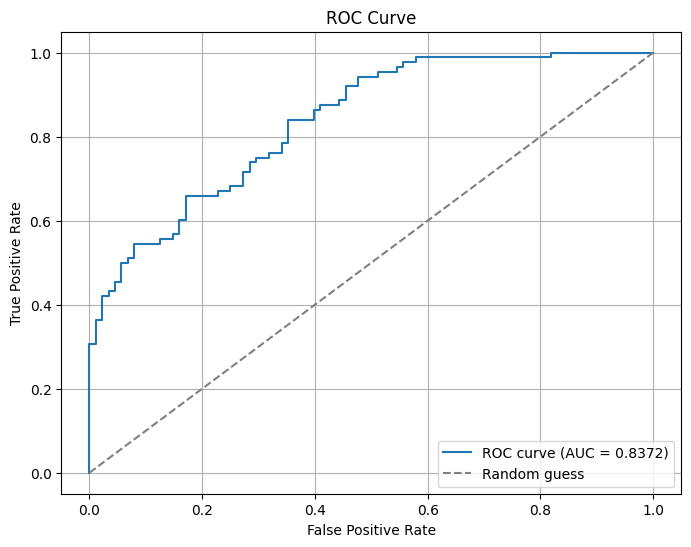

In [22]:
# 확률 예측 (양성 클래스일 확률만)
y_proba = model.predict_proba(X_test)[:, 1]

# fpr: false positive rate, tpr: true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# AUC 점수 계산
roc_auc = roc_auc_score(y_test, y_proba)

# ROC 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


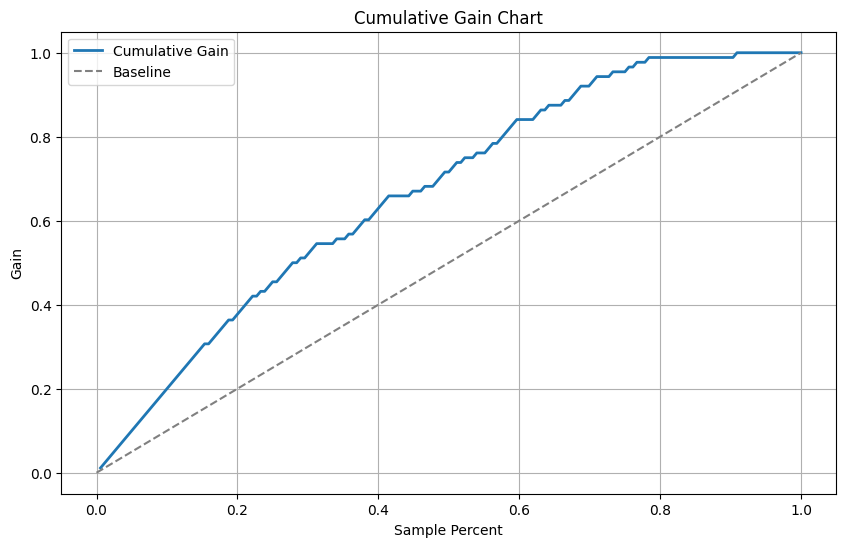

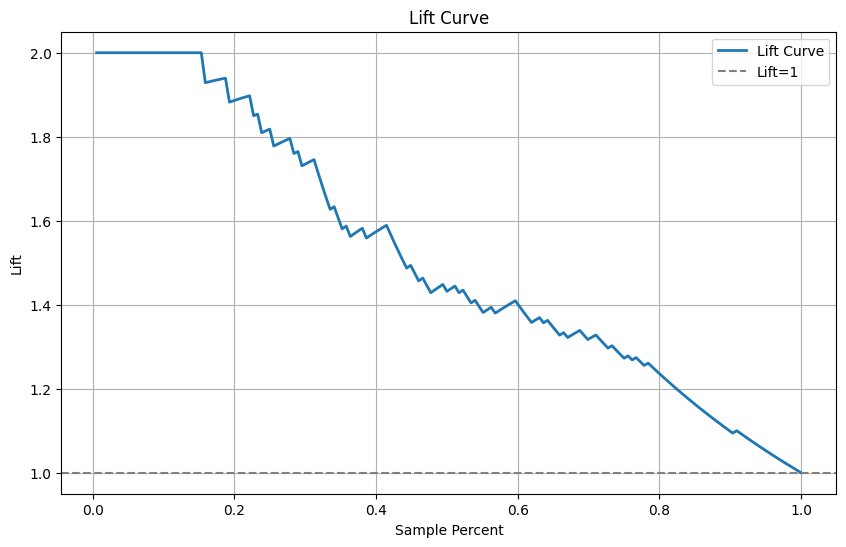

In [23]:
# 예측 확률 추출 (양성 클래스 기준)
y_probs = model.predict_proba(X_test)[:, 1]

# 실제값과 예측확률로 데이터프레임 생성 후 정렬
df = pd.DataFrame({'y_true': y_test, 'y_prob': y_probs})
df = df.sort_values('y_prob', ascending=False).reset_index(drop=True)

# 누적 양성 수 계산
df['cumulative_true'] = df['y_true'].cumsum()

# 전체 양성 샘플 수와 전체 샘플 수
total_positives = df['y_true'].sum()
total_samples = len(df)

# 누적 샘플 비율 및 Gain/Lift 계산
df['sample_percent'] = (df.index + 1) / total_samples
df['gain'] = df['cumulative_true'] / total_positives
df['lift'] = df['gain'] / df['sample_percent']

# 누적 이득 곡선 (Cumulative Gain Chart)
plt.figure(figsize=(10, 6))
plt.plot(df['sample_percent'], df['gain'], label='Cumulative Gain', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline')
plt.xlabel('Sample Percent')
plt.ylabel('Gain')
plt.title('Cumulative Gain Chart')
plt.legend()
plt.grid(True)
plt.show()

# 향상도 곡선 (Lift Curve)
plt.figure(figsize=(10, 6))
plt.plot(df['sample_percent'], df['lift'], label='Lift Curve', linewidth=2)
plt.axhline(y=1, color='gray', linestyle='--', label='Lift=1')
plt.xlabel('Sample Percent')
plt.ylabel('Lift')
plt.title('Lift Curve')
plt.legend()
plt.grid(True)
plt.show()



##10. 결과해석
-----
1. Glucose, Age, Pregnancies, BMI 컬럼은 Outcome에 큰 영향을 미침
2. 모델 성능이 학습셋과 테스트셋에서 큰 차이가 없음 -> 과적합 우려 없음
3. AUC가 0.83이상으로 양호한 분류 능력 확인
4. 변수간 다중공선성 없음 -> 변수 해석 가능
5. 누적 이득 곡선을 통해 모델이 상위 예측 구간에서 실제 양성 클래스를 효과적으로 분류하고 있음을 확인 -> 예측 순위가 양성 클래스 탐지에 유효
6. 향상도 곡선을 통해 상위 20~30% 예측 구간에서 무작위 예측 대비 약 2배 수준의 성능 확보